# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## RRI の変化・イベントに対する反応

### 目的

`06` `07` で、RRI の**水準**（25 以上）は 2018 年以降リターン情報を失っていることが分かった。
ここでは水準ではなく**変化**に情報が残っているかを確認する。レピュテーション事案の発生直後（RRI が急上昇した月）の
価格反応は、水準が織り込まれているかどうかとは別に存在しうる。

### 定義

- $\Delta_1 = \text{RRI}_t - \text{RRI}_{t-1}$（前月もスコアがある銘柄のみ）
- イベント（いずれも S3〜S5、当月にスコアあり）
  - **新規 25 以上**: $\text{RRI}_t \ge 25$ かつ $\text{RRI}_{t-1} < 25$
  - **大幅上昇**: $\Delta_1 \ge 10$
  - **25 未満へ離脱**: $\text{RRI}_t < 25$ かつ $\text{RRI}_{t-1} \ge 25$
- 相対リターン: 銘柄リターン − 参照（S3〜S5 スコアあり銘柄の等ウェイト）。`rtn`（トータル）と `srtn`（固有）の両方
- **イベントスタディ**: イベント月 $t$ を 0 とし、$h = -6, \dots, +12$ か月の相対リターンをイベントごとに集め、
  平均累積相対リターン（$h \le 0$ は事前、$h \ge 1$ は事後）を描く。イベントは重なるので有意性は次のポートフォリオで判断する
- **カレンダータイム・ポートフォリオ**: 各月、過去 $k$ か月（$k = 1, 3, 6, 12$）にイベントがあった銘柄を等ウェイトで保有し、
  参照との差を期間別（前期 = 〜2017、後期 = 2018〜）に集計する
- **IC**: $-\Delta_1$、$-\Delta_3$ と翌月リターンの Spearman IC

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, forward_returns, ic_summary, information_coefficient, portfolio_returns, weight_portfolio

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
RISK_MODEL = "GEMLT"
RETURN_COLS = {"rtn": "トータル", "srtn": "固有"}
START, END = 200801, 202606
N_SIZE_BINS = 5
SIZE_BINS_USED = [3, 4, 5]
TAIL_LEVEL = 24.5
JUMP = 10
PRE, POST = 6, 12
HOLD_MONTHS = [1, 3, 6, 12]
SPLIT = "2018-01-01"
PERIODS = {"全期間": (None, None), "前期 〜2017": (None, "2017-12-31"), "後期 2018〜": (SPLIT, None)}

store = InputStore(INPUT_ROOT)

### 1. データ読み込みとイベント定義

In [2]:
univ = store.universe(START, END)
score = store.alpha(SCORE, START, END)
returns = {col: store.returns(RISK_MODEL, col, START, 202607) for col in RETURN_COLS}

score_u = score.where(univ.notna()).reindex(columns=univ.columns)
log_size = np.log(univ.where(univ > 0))
size_bin = np.ceil(log_size.rank(axis=1, pct=True) * N_SIZE_BINS).clip(1, N_SIZE_BINS)
seg = size_bin.isin(SIZE_BINS_USED)
s_seg = score_u.where(seg)
scored = s_seg.notna()
prev = score_u.shift(1)                      # 前月のスコア（ユニバース所属は問わない）
delta1 = (s_seg - prev).where(scored & prev.notna())
delta3 = (s_seg - score_u.shift(3)).where(scored & score_u.shift(3).notna())

events = {
    "新規 25以上": (s_seg >= TAIL_LEVEL) & (prev < TAIL_LEVEL),
    f"大幅上昇 (Δ {JUMP}以上)": delta1 >= JUMP,
    "25未満へ離脱": (s_seg < TAIL_LEVEL) & (prev >= TAIL_LEVEL) & scored,
}
events = {k: v.fillna(False).astype(bool) for k, v in events.items()}

# 参照リターンと相対リターンパネル（日付 = リターン月）
ref = {col: portfolio_returns(weight_portfolio(scored), r) for col, r in returns.items()}
rel = {col: r.sub(ref[col].reindex(r.index), axis=0) for col, r in returns.items()}

n_events = pd.DataFrame({k: v.sum(axis=1) for k, v in events.items()})
print(f"期間: {univ.index.min().date()} 〜 {univ.index.max().date()} ({len(univ)} か月)")
print("イベント数（合計）:", n_events.sum().to_dict())
print("月あたり平均:", n_events.mean().round(2).to_dict())
display(n_events.groupby(n_events.index.year).sum())

期間: 2008-01-31 〜 2026-06-30 (222 か月)
イベント数（合計）: {'新規 25以上': 1618, '大幅上昇 (Δ 10以上)': 1166, '25未満へ離脱': 1613}
月あたり平均: {'新規 25以上': 7.29, '大幅上昇 (Δ 10以上)': 5.25, '25未満へ離脱': 7.27}


,新規 25以上,大幅上昇 (Δ 10以上),25未満へ離脱
2008,48,32,49
2009,33,34,36
2010,38,40,36
2011,84,54,78
2012,101,58,96
2013,73,63,69
2014,62,53,63
2015,58,39,65
2016,49,44,49
2017,61,47,54


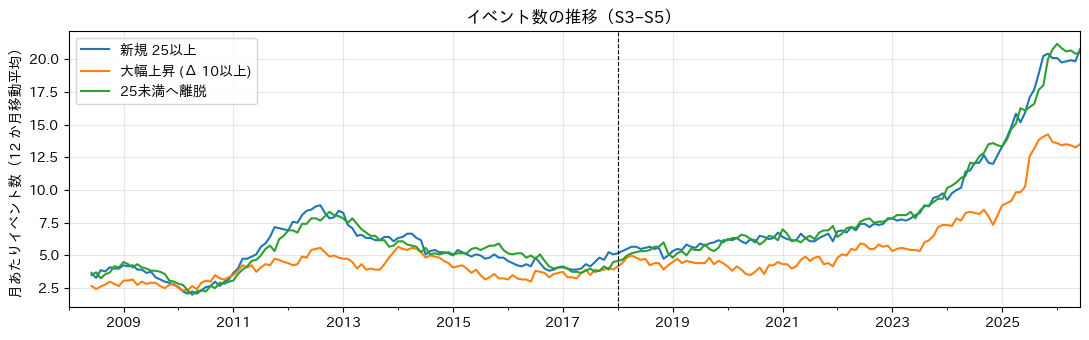

Δ1 の分布（前月スコアあり）


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,38963.0,0.05,4.29,-15.0,-9.0,-2.0,-1.0,0.0,0.0,5.0,24.0,46.0


Δ1 = 0 の割合: 46.7%, |Δ1| ≥ 10 の割合: 3.82%


In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
n_events.rolling(12, min_periods=6).mean().plot(ax=ax)
ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
ax.set_ylabel("月あたりイベント数（12 か月移動平均）")
ax.set_title("イベント数の推移（S3–S5）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

d = delta1.stack()
print("Δ1 の分布（前月スコアあり）")
display(d.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2).to_frame().T)
print(f"Δ1 = 0 の割合: {(d == 0).mean():.1%}, |Δ1| ≥ {JUMP} の割合: {(d.abs() >= JUMP).mean():.2%}")

### 2. イベントスタディ

イベント月を 0 とし、前後の平均累積相対リターンを描く。事後（$h \ge 1$）は $h = 1$ から累積、
事前（$h \le 0$）は $h = 0$ に向けて累積（$h = -6$ を起点）。期間別（前期・後期）に分ける。

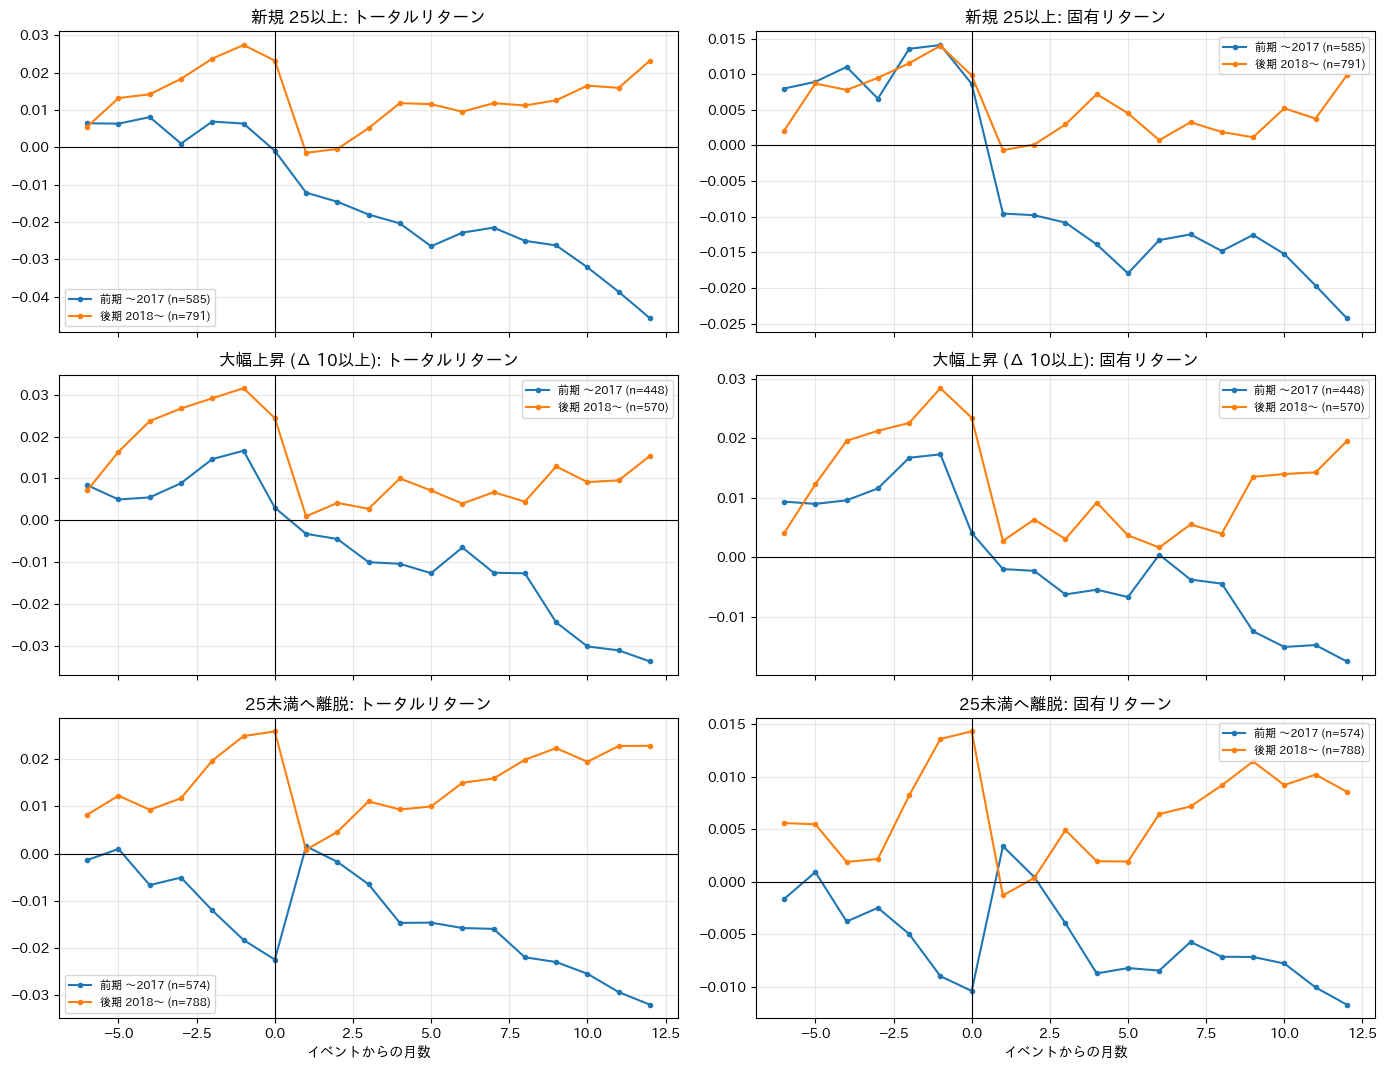

In [4]:
def event_paths(event: pd.DataFrame, rel_panel: pd.DataFrame) -> pd.DataFrame:
    """各イベントの h = -PRE..+POST の相対リターンを行列で返す（行 = イベント、列 = h）。"""
    idx = rel_panel.index
    arr = rel_panel.to_numpy()
    col_pos = {c: i for i, c in enumerate(rel_panel.columns)}
    rows, keys = [], []
    for date, code in zip(*np.where(event.to_numpy())):
        t = idx.searchsorted(event.index[date])          # イベント月のリターン行
        c = col_pos.get(event.columns[code])
        if c is None or t - PRE < 0 or t + POST >= len(idx):
            continue
        rows.append(arr[t - PRE : t + POST + 1, c])
        keys.append((event.index[date], event.columns[code]))
    out = pd.DataFrame(rows, columns=range(-PRE, POST + 1), index=pd.MultiIndex.from_tuples(keys, names=["date", "code"]))
    return out


def cum_path(paths: pd.DataFrame) -> pd.Series:
    """平均累積相対リターン: 事後は h=1 から、事前は h=-PRE から h=0 まで累積（対数近似ではなく単純和）。"""
    m = paths.mean()
    pre = m.loc[-PRE:0].cumsum()
    post = m.loc[1:POST].cumsum()
    return pd.concat([pre, post])


paths = {(k, col): event_paths(ev, rel[col]) for k, ev in events.items() for col in RETURN_COLS}

fig, axes = plt.subplots(len(events), 2, figsize=(14, 3.6 * len(events)), sharex=True)
for i, k in enumerate(events):
    for j, (col, label) in enumerate(RETURN_COLS.items()):
        ax = axes[i, j]
        pth = paths[(k, col)]
        for pname, per in list(PERIODS.items())[1:]:
            lo, hi = per
            sel = pth.loc[(slice(lo, hi), slice(None)), :] if True else pth
            dates = pth.index.get_level_values("date")
            mask = (dates >= (lo or dates.min())) & (dates <= (hi or dates.max()))
            sub = pth[mask]
            if len(sub) < 10:
                continue
            cp = cum_path(sub)
            ax.plot(cp.index, cp.to_numpy(), marker="o", markersize=3, label=f"{pname} (n={len(sub)})")
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_title(f"{k}: {label}リターン")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
axes[-1, 0].set_xlabel("イベントからの月数")
axes[-1, 1].set_xlabel("イベントからの月数")
plt.tight_layout()
plt.show()

In [5]:
# 事前 (-6..0) と 事後 (+1..+3, +1..+12) の平均累積相対リターンの数表（固有リターン）
rows = {}
for k in events:
    for pname, per in PERIODS.items():
        pth = paths[(k, "srtn")]
        dates = pth.index.get_level_values("date")
        lo, hi = per
        sub = pth[(dates >= (lo or dates.min())) & (dates <= (hi or dates.max()))]
        m = sub.mean()
        se = sub.std() / np.sqrt(len(sub))
        rows[(k, pname)] = {
            "n": len(sub),
            "事前 -6..0": m.loc[-PRE:0].sum(),
            "当月 0": m.loc[0],
            "事後 +1..+3": m.loc[1:3].sum(),
            "事後 +1..+12": m.loc[1:12].sum(),
            "事後 +1..+3 t値": m.loc[1:3].sum() / np.sqrt((se.loc[1:3] ** 2).sum()),
            "事後 +1..+12 t値": m.loc[1:12].sum() / np.sqrt((se.loc[1:12] ** 2).sum()),
        }
tbl = pd.DataFrame(rows).T
tbl.index.names = ["イベント", "期間"]
print("固有リターン（相対）。t 値はイベント独立を仮定した参考値")
display(tbl.round(4))

固有リターン（相対）。t 値はイベント独立を仮定した参考値


n  事前 -6..0    当月 0  事後 +1..+3  事後 +1..+12  事後 +1..+3 t値  事後 +1..+12 t値
イベント          期間                                                                                    
新規 25以上       全期間       1376.0    0.0093 -0.0047    -0.0029     -0.0044       -0.6873        -0.5570
              前期 〜2017   585.0    0.0087 -0.0055    -0.0108     -0.0243       -1.7798        -1.9791
              後期 2018〜   791.0    0.0098 -0.0042     0.0030      0.0099        0.5169         0.9361
大幅上昇 (Δ 10以上) 全期間       1018.0    0.0149 -0.0086    -0.0010      0.0035       -0.2128         0.3599
              前期 〜2017   448.0    0.0041 -0.0132    -0.0062     -0.0175       -0.8838        -1.1940
              後期 2018〜   570.0    0.0234 -0.0050     0.0031      0.0195        0.4603         1.5047
25未満へ離脱       全期間       1362.0    0.0039 -0.0002     0.0012      0.0001        0.2817         0.0126
              前期 〜2017   574.0   -0.0104 -0.0014    -0.0040     -0.0117       -0.6552        -0.9502
              後期 2018〜   788.0    0.0143  0.0007     0.0049      0.0085        0.8466         0.8169

### 3. カレンダータイム・ポートフォリオ

過去 $k$ か月にイベントがあった銘柄を等ウェイトで保有した場合の、参照に対する超過。
イベントの重なりを自然に扱えるので、有意性はこちらで判断する。

In [6]:
def calendar_stats(event: pd.DataFrame, col: str, k: int) -> dict[str, dict]:
    member = event.rolling(k, min_periods=1).max().astype(bool) & scored
    r = portfolio_returns(weight_portfolio(member), returns[col])
    z = (r - ref[col].reindex(r.index)).dropna()
    n = member.sum(axis=1)
    out = {}
    for pname, per in PERIODS.items():
        lo, hi = per
        zz = z.loc[lo:hi]
        nn = n.loc[lo:hi]
        out[pname] = {"年率超過": zz.mean() * 12, "TE": zz.std() * np.sqrt(12), "IR": zz.mean() / zz.std() * np.sqrt(12), "勝率": (zz > 0).mean(), "平均銘柄数": nn.mean(), "空の月割合": (nn == 0).mean()}
    return out

rows = {}
for k_name, ev in events.items():
    for col, label in RETURN_COLS.items():
        for k in HOLD_MONTHS:
            for pname, st in calendar_stats(ev, col, k).items():
                rows[(k_name, label, f"{k}か月", pname)] = st
cal = pd.DataFrame(rows).T
cal.index.names = ["イベント", "リターン", "保有", "期間"]
display(cal.xs("固有", level="リターン").round(3))

年率超過     TE     IR     勝率   平均銘柄数  空の月割合
イベント          保有   期間                                                 
新規 25以上       1か月  全期間      -0.052  0.132 -0.389  0.419   7.288  0.009
                   前期 〜2017 -0.119  0.140 -0.852  0.361   5.058  0.017
                   後期 2018〜  0.027  0.120  0.221  0.485   9.912  0.000
              3か月  全期間      -0.014  0.085 -0.162  0.437  20.518  0.005
                   前期 〜2017 -0.032  0.095 -0.333  0.420  14.242  0.008
                   後期 2018〜  0.007  0.073  0.089  0.456  27.902  0.000
              6か月  全期間      -0.017  0.057 -0.290  0.455  35.527  0.005
                   前期 〜2017 -0.015  0.061 -0.252  0.445  24.708  0.008
                   後期 2018〜 -0.018  0.052 -0.341  0.466  48.255  0.000
              12か月 全期間      -0.014  0.048 -0.295  0.450  53.743  0.005
                   前期 〜2017 -0.021  0.052 -0.408  0.420  37.692  0.008
                   後期 2018〜 -0.006  0.044 -0.142  0.485  72.627  0.000
大幅上昇 (Δ 10以上) 1か月  全期間      -0.015  0.166 -0.092  0.482   5.252  0.027
                   前期 〜2017 -0.021  0.164 -0.129  0.471   3.867  0.033
                   後期 2018〜 -0.008  0.169 -0.050  0.495   6.882  0.020
              3か月  全期間      -0.003  0.095 -0.033  0.477  14.946  0.005
                   前期 〜2017  0.003  0.102  0.026  0.454  10.967  0.008
                   後期 2018〜 -0.010  0.088 -0.113  0.505  19.627  0.000
              6か月  全期間      -0.013  0.066 -0.191  0.477  28.014  0.005
                   前期 〜2017 -0.004  0.067 -0.067  0.462  20.458  0.008
                   後期 2018〜 -0.022  0.065 -0.336  0.495  36.902  0.000
              12か月 全期間      -0.006  0.052 -0.115  0.455  49.257  0.005
                   前期 〜2017 -0.018  0.055 -0.328  0.429  35.450  0.008
                   後期 2018〜  0.008  0.048  0.165  0.485  65.500  0.000
25未満へ離脱       1か月  全期間       0.027  0.156  0.173  0.459   7.266  0.023
                   前期 〜2017  0.082  0.189  0.432  0.504   4.958  0.033
                   後期 2018〜 -0.036  0.102 -0.355  0.408   9.980  0.010
              3か月  全期間       0.012  0.087  0.135  0.509  20.689  0.005
                   前期 〜2017  0.024  0.102  0.234  0.496  14.125  0.008
                   後期 2018〜 -0.002  0.066 -0.034  0.524  28.412  0.000
              6か月  全期間      -0.011  0.058 -0.197  0.464  35.959  0.005
                   前期 〜2017 -0.013  0.063 -0.208  0.420  24.542  0.008
                   後期 2018〜 -0.009  0.051 -0.182  0.515  49.392  0.000
              12か月 全期間      -0.006  0.050 -0.116  0.459  54.748  0.005
                   前期 〜2017 -0.004  0.054 -0.067  0.454  37.575  0.008
                   後期 2018〜 -0.008  0.046 -0.184  0.466  74.951  0.000

In [7]:
print("トータルリターン")
display(cal.xs("トータル", level="リターン").round(3))

トータルリターン


年率超過     TE     IR     勝率   平均銘柄数  空の月割合
イベント          保有   期間                                                 
新規 25以上       1か月  全期間      -0.078  0.154 -0.503  0.441   7.288  0.009
                   前期 〜2017 -0.171  0.172 -0.995  0.345   5.058  0.017
                   後期 2018〜  0.030  0.125  0.240  0.553   9.912  0.000
              3か月  全期間      -0.023  0.090 -0.251  0.437  20.518  0.005
                   前期 〜2017 -0.063  0.096 -0.655  0.387  14.242  0.008
                   後期 2018〜  0.024  0.080  0.305  0.495  27.902  0.000
              6か月  全期間      -0.019  0.065 -0.300  0.450  35.527  0.005
                   前期 〜2017 -0.037  0.071 -0.526  0.420  24.708  0.008
                   後期 2018〜  0.001  0.057  0.016  0.485  48.255  0.000
              12か月 全期間      -0.018  0.055 -0.333  0.446  53.743  0.005
                   前期 〜2017 -0.043  0.060 -0.718  0.370  37.692  0.008
                   後期 2018〜  0.010  0.048  0.210  0.534  72.627  0.000
大幅上昇 (Δ 10以上) 1か月  全期間      -0.019  0.193 -0.101  0.450   5.252  0.027
                   前期 〜2017 -0.019  0.204 -0.092  0.437   3.867  0.033
                   後期 2018〜 -0.020  0.180 -0.112  0.466   6.882  0.020
              3か月  全期間      -0.003  0.111 -0.027  0.495  14.946  0.005
                   前期 〜2017 -0.009  0.128 -0.069  0.445  10.967  0.008
                   後期 2018〜  0.004  0.090  0.040  0.553  19.627  0.000
              6か月  全期間      -0.017  0.074 -0.228  0.473  28.014  0.005
                   前期 〜2017 -0.023  0.077 -0.294  0.420  20.458  0.008
                   後期 2018〜 -0.010  0.069 -0.143  0.534  36.902  0.000
              12か月 全期間      -0.012  0.059 -0.207  0.459  49.257  0.005
                   前期 〜2017 -0.032  0.065 -0.495  0.420  35.450  0.008
                   後期 2018〜  0.011  0.051  0.213  0.505  65.500  0.000
25未満へ離脱       1か月  全期間       0.037  0.173  0.214  0.482   7.266  0.023
                   前期 〜2017  0.072  0.214  0.336  0.471   4.958  0.033
                   後期 2018〜 -0.003  0.110 -0.026  0.495   9.980  0.010
              3か月  全期間       0.021  0.098  0.212  0.495  20.689  0.005
                   前期 〜2017  0.019  0.115  0.162  0.487  14.125  0.008
                   後期 2018〜  0.023  0.075  0.312  0.505  28.412  0.000
              6か月  全期間      -0.010  0.069 -0.149  0.446  35.959  0.005
                   前期 〜2017 -0.026  0.075 -0.354  0.378  24.542  0.008
                   後期 2018〜  0.008  0.061  0.137  0.524  49.392  0.000
              12か月 全期間      -0.006  0.058 -0.106  0.441  54.748  0.005
                   前期 〜2017 -0.018  0.063 -0.277  0.395  37.575  0.008
                   後期 2018〜  0.007  0.051  0.140  0.495  74.951  0.000

### 4. 変化量の IC

$-\Delta_1$、$-\Delta_3$（上昇 = 悪い）と翌月リターンの Spearman IC。$\Delta = 0$ が多数を占めるため、
非ゼロの変化があった銘柄に限った IC も併記する。

In [8]:
seg_univ = univ.where(seg)
rows = {}
for col, label in RETURN_COLS.items():
    fwd1 = forward_returns(returns[col], 1)
    defs = {
        "−Δ1（全銘柄）": -delta1,
        "−Δ1（Δ≠0 のみ）": (-delta1).where(delta1 != 0),
        "−Δ3（全銘柄）": -delta3,
        "−Δ3（Δ≠0 のみ）": (-delta3).where(delta3 != 0),
    }
    for name, s in defs.items():
        ic = information_coefficient(s, fwd1, seg_univ, "spearman", min_obs=10)
        for pname, per in PERIODS.items():
            lo, hi = per
            summ = ic_summary(ic.loc[lo:hi])
            rows[(name, label, pname)] = summ[["mean", "std", "icir", "t_stat", "hit_rate", "n"]]
ic_tbl = pd.DataFrame(rows).T
ic_tbl.index.names = ["定義", "リターン", "期間"]
display(ic_tbl.round(3))

mean    std   icir  t_stat  hit_rate      n
定義          リターン 期間                                                    
−Δ1（全銘柄）    トータル 全期間       0.000  0.089  0.002   0.032     0.525  221.0
                 前期 〜2017  0.004  0.094  0.041   0.446     0.563  119.0
                 後期 2018〜 -0.004  0.082 -0.049  -0.497     0.480  102.0
−Δ1（Δ≠0 のみ） トータル 全期間       0.009  0.128  0.068   1.011     0.498  221.0
                 前期 〜2017  0.019  0.136  0.140   1.529     0.529  119.0
                 後期 2018〜 -0.003  0.118 -0.029  -0.288     0.461  102.0
−Δ3（全銘柄）    トータル 全期間       0.002  0.090  0.018   0.267     0.530  219.0
                 前期 〜2017  0.012  0.099  0.124   1.339     0.581  117.0
                 後期 2018〜 -0.011  0.077 -0.137  -1.384     0.471  102.0
−Δ3（Δ≠0 のみ） トータル 全期間       0.008  0.132  0.063   0.929     0.530  219.0
                 前期 〜2017  0.023  0.153  0.147   1.590     0.590  117.0
                 後期 2018〜 -0.008  0.102 -0.078  -0.788     0.461  102.0
−Δ1（全銘柄）    固有   全期間       0.002  0.089  0.023   0.340     0.548  221.0
                 前期 〜2017  0.006  0.095  0.067   0.734     0.588  119.0
                 後期 2018〜 -0.003  0.081 -0.038  -0.385     0.500  102.0
−Δ1（Δ≠0 のみ） 固有   全期間       0.008  0.121  0.070   1.038     0.520  221.0
                 前期 〜2017  0.017  0.132  0.129   1.408     0.563  119.0
                 後期 2018〜 -0.002  0.106 -0.016  -0.157     0.471  102.0
−Δ3（全銘柄）    固有   全期間       0.001  0.086  0.008   0.119     0.498  219.0
                 前期 〜2017  0.009  0.098  0.096   1.035     0.538  117.0
                 後期 2018〜 -0.009  0.069 -0.133  -1.342     0.451  102.0
−Δ3（Δ≠0 のみ） 固有   全期間       0.005  0.126  0.036   0.533     0.516  219.0
                 前期 〜2017  0.013  0.146  0.090   0.969     0.564  117.0
                 後期 2018〜 -0.005  0.097 -0.054  -0.549     0.461  102.0

### 5. 所見

**イベントの頻度**

- 新規 25 以上は合計 1,618 件（月 7.3 件）、25 未満へ離脱も 1,613 件とほぼ同数で、RRI が 25 前後を頻繁に行き来している
  （`05` で見た 25 以上の回転率 600% 超と整合）。大幅上昇（Δ1 ≥ 10）は 1,166 件（月 5.3 件）。
- 件数は 2023 年以降に急増（2025 年は新規 25 以上が 241 件）。カバレッジ拡張に伴い、閾値をまたぐ銘柄が増えている。
- Δ1 はゼロが 47%、|Δ1| ≥ 10 は 3.8%。変化のほとんどは ±1〜2 の小さな揺れ。

**イベントスタディ（固有リターン、相対）**

| イベント | 期間 | n | 事前 −6..0 | 当月 0 | 事後 +1..+3 | 事後 +1..+12 |
| --- | --- | --- | --- | --- | --- | --- |
| 新規 25 以上 | 前期 | 585 | +0.9% | −0.6% | −1.1%（t −1.8） | −2.4%（t −2.0） |
| 新規 25 以上 | 後期 | 791 | +1.0% | −0.4% | +0.3% | +1.0% |
| 大幅上昇 | 前期 | 448 | +0.4% | −1.3% | −0.6% | −1.8% |
| 大幅上昇 | 後期 | 570 | +2.3% | −0.5% | +0.3% | +2.0% |

- **当月（h = 0）の反応は両期間で負**（新規 25 以上 −0.6% / −0.4%、大幅上昇 −1.3% / −0.5%）。事案の発生月に価格は下がる。
  ただし月末のスコアで観測するため、この反応には乗れない。
- **事後のドリフトは前期のみ**。前期は事後 12 か月で −2.4%（t −2.0）と緩やかに劣後が続いたが、後期は事後 3 か月で +0.3%、
  12 か月で +1.0% とむしろ小幅に戻る。「発生直後に売る」戦略は後期には機能しない。
- 事前 6 か月は両期間とも正（+0.9〜+2.3%）。RRI が上がる直前まで相対的に堅調だった銘柄がイベントを起こしている。
  注目度（報道量）が株価上昇の後に増えるという方向の関係で、リターン予測とは逆向き。
- 25 未満へ離脱は前期に事後も劣後が続き（−1.2%）、後期は小幅に正。「離脱 = 好材料」という反応は無い。

**カレンダータイム・ポートフォリオ（固有リターン、参照対比）**

| 保有 | 新規 25 以上 前期 | 新規 25 以上 後期 | 大幅上昇 前期 | 大幅上昇 後期 |
| --- | --- | --- | --- | --- |
| 1 か月 | −11.9% / IR −0.85 | +2.7% / 0.22 | −2.1% / −0.13 | −0.8% / −0.05 |
| 3 か月 | −3.2% / −0.33 | +0.7% / 0.09 | +0.3% / 0.03 | −1.0% / −0.11 |
| 12 か月 | −2.1% / −0.41 | −0.6% / −0.14 | −1.8% / −0.33 | +0.8% / 0.17 |

- 前期の「新規 25 以上を 1 か月保有」は IR −0.85 と明確な劣後（銘柄数 5、TE 14% と粗いが勝率 36%）。
  後期は符号が反転し +2.7%。大幅上昇はどちらの期間でも有意な反応が無い。
- 保有期間を延ばすほど水準効果（`05` `06`）に近づき、後期はいずれもゼロ近傍。

**変化量の IC**

- −Δ1、−Δ3 の Spearman IC は全期間・両リターンでほぼゼロ（|t| < 1.6）。Δ ≠ 0 に限っても前期に t 1.4〜1.6 が最大で、
  後期はすべて負。変化量の大小には情報が無い。

**まとめ**

1. RRI の変化にも、後期（2018 年〜）はリターン情報が無い。事案発生月の同時反応（−0.4〜−0.5%）は残っているが、
   スコアが観測できる月末には織り込み済みで、その後のドリフトは消えている。前期に存在した「発生後 1〜12 か月の劣後」は
   **市場の織り込みが速くなった**と解釈するのが自然。
2. 水準（`06` `07`）と変化（本 Notebook）の両方で後期の効果が無いため、**RRI をリターン予測シグナルとして採用する根拠は現状無い**。
3. 以降は RRI を「レピュテーション事案の除外」というリスク管理用途に限定し、除外による回転率・税コスト・
   トラッキングエラーへの影響を `alphaeval.tax` で評価するステップに進む。